# Version 3 clean notebook: volume-current closed eddy model

This notebook keeps only the Version 3 physics path and all functions are defined locally in the notebook.

The model follows the derivation in the screenshots:

$$E = -i\omega A_0 - \nabla\phi$$

$$J = \sigma E$$

$$\nabla\cdot J = 0, \qquad J\cdot\hat n = 0$$

$$B_{sec,z}(r) = {\mu_0 \over 4\pi}\int {\left[J(r')\times(r-r')\right]\cdot\hat z \over |r-r'|^3}\,dV'.$$

Important implementation choice: the pickup field is computed only from cell-centred volume current density `J dV`, matching the screenshot summation. There is no face-current Biot-Savart evaluation in this notebook.


In [21]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.csgraph import connected_components
from discretize import TensorMesh

warnings.filterwarnings("ignore")

MU0 = 4.0 * np.pi * 1e-7
mpl.rcParams.update({"font.size": 11})

print("Imports loaded. This notebook does not import scripts/fs_magnetostatic/*.py")


Imports loaded. This notebook does not import scripts/fs_magnetostatic/*.py


## Experiment knobs

Edit this cell to change the sample, mesh, air padding, scan, pickup disk, and SVD settings.

`SAMPLE_Z` is now represented exactly when `FIT_SAMPLE_Z_EXACTLY = True`. The code chooses an integer number of z cells near `DZ_TARGET`, then slightly adjusts the actual `DZ` so the tissue thickness is exactly the requested value. For example, `SAMPLE_Z = 0.001` and `DZ_TARGET = 0.0004` gives 3 z cells with `DZ = 0.333... mm`.


In [22]:
cfg_path = Path("config.json")
with cfg_path.open("r") as f:
    cfg = json.load(f)

props = cfg["properties"]
rf = cfg["rf"]
coil = cfg["excitation"]

# -----------------------------------------------------------------------------
# Mesh and sample geometry
# -----------------------------------------------------------------------------
# Target cell widths. For z, this can be treated as a target resolution rather
# than an exact cell width so SAMPLE_Z can be represented exactly.
DX_TARGET = 0.0004
DY_TARGET = 0.0004
DZ_TARGET = 0.0004
FIT_SAMPLE_Z_EXACTLY = True

# Requested conducting sample size. These can be any positive values.
SAMPLE_X = 0.060
SAMPLE_Y = 0.040
SAMPLE_Z = 0.001       # exactly 1 mm when FIT_SAMPLE_Z_EXACTLY=True
SAMPLE_CENTER = np.array([0.0, 0.0, -0.005], dtype=float)

# Non-conducting padding in whole cells: negative side, positive side.
AIR_X = (0, 0)
AIR_Y = (0, 0)
AIR_Z = (0, 0)

# Elliptical scar in the sample x-y plane. It spans all sample z layers.
SCAR_CENTER_XY = np.array([0.010, 0.0], dtype=float)
SCAR_RX = 0.008
SCAR_RY = 0.004


def choose_cells(length, target_h, name, *, exact=False):
    """Choose whole cells for an axis.

    exact=False: use target_h exactly and cover the requested length.
    exact=True: choose enough cells near target_h, then adjust h so length is exact.
    """
    if length <= 0:
        raise ValueError(f"{name} must be positive.")
    if target_h <= 0:
        raise ValueError(f"{name} target cell width must be positive.")

    n = max(1, int(np.ceil(length / target_h - 1e-12)))
    if exact:
        h = length / n
        actual = length
        if not np.isclose(h, target_h, rtol=0.0, atol=1e-12):
            print(f"{name}: requested {length:g} m -> {n} cells, adjusted h = {h:g} m")
    else:
        h = target_h
        actual = n * h
        if not np.isclose(actual, length, rtol=0.0, atol=1e-12):
            print(f"{name}: requested {length:g} m -> using {n} cells = {actual:g} m")
    return n, h, actual


NX_SAMPLE, DX, SAMPLE_X_ACTUAL = choose_cells(SAMPLE_X, DX_TARGET, "sample x", exact=False)
NY_SAMPLE, DY, SAMPLE_Y_ACTUAL = choose_cells(SAMPLE_Y, DY_TARGET, "sample y", exact=False)
NZ_SAMPLE, DZ, SAMPLE_Z_ACTUAL = choose_cells(SAMPLE_Z, DZ_TARGET, "sample z", exact=FIT_SAMPLE_Z_EXACTLY)

NX = NX_SAMPLE + AIR_X[0] + AIR_X[1]
NY = NY_SAMPLE + AIR_Y[0] + AIR_Y[1]
NZ = NZ_SAMPLE + AIR_Z[0] + AIR_Z[1]

MESH_X = NX * DX
MESH_Y = NY * DY
MESH_Z = NZ * DZ

ORIGIN = np.array([
    SAMPLE_CENTER[0] - 0.5 * SAMPLE_X_ACTUAL - AIR_X[0] * DX,
    SAMPLE_CENTER[1] - 0.5 * SAMPLE_Y_ACTUAL - AIR_Y[0] * DY,
    SAMPLE_CENTER[2] - 0.5 * SAMPLE_Z_ACTUAL - AIR_Z[0] * DZ,
])

geometry = {
    "dx": DX,
    "dy": DY,
    "dz": DZ,
    "nx": NX,
    "ny": NY,
    "nz": NZ,
    "origin": ORIGIN,
    "mesh_size": np.array([MESH_X, MESH_Y, MESH_Z], dtype=float),
    "sample_requested": np.array([SAMPLE_X, SAMPLE_Y, SAMPLE_Z], dtype=float),
    "sample_size": np.array([SAMPLE_X_ACTUAL, SAMPLE_Y_ACTUAL, SAMPLE_Z_ACTUAL], dtype=float),
    "sample_shape": (NX_SAMPLE, NY_SAMPLE, NZ_SAMPLE),
    "sample_center": SAMPLE_CENTER,
    "air_cells": {"x": AIR_X, "y": AIR_Y, "z": AIR_Z},
    "cell_width_target": np.array([DX_TARGET, DY_TARGET, DZ_TARGET], dtype=float),
    "fit_sample_z_exactly": FIT_SAMPLE_Z_EXACTLY,
    "scar_center_xy": SCAR_CENTER_XY,
    "scar_rx": SCAR_RX,
    "scar_ry": SCAR_RY,
    # Compatibility names used by plotting helpers.
    "tissue_length_x": SAMPLE_X_ACTUAL,
    "tissue_length_y": SAMPLE_Y_ACTUAL,
    "tissue_thickness_z": SAMPLE_Z_ACTUAL,
    "tissue_center_x": SAMPLE_CENTER[0],
    "tissue_center_y": SAMPLE_CENTER[1],
    "tissue_center_z": SAMPLE_CENTER[2],
    "scar_center_x": SCAR_CENTER_XY[0],
    "scar_center_y": SCAR_CENTER_XY[1],
    "scar_center_z": SAMPLE_CENTER[2],
    "scar_radius_x": SCAR_RX,
    "scar_radius_y": SCAR_RY,
}

freq = float(rf["frequency"])
omega = 2.0 * np.pi * freq

coil_radius = float(coil["radius_m"])
coil_center = np.asarray(coil["center_xyz"], dtype=float)
coil_current = float(coil["current_A"])
coil_segments = int(coil["n_segments"])
chunk = int(coil.get("chunk_size") or 4096)

ref_xyz = coil.get("reference_xyz")
ref_xyz = SAMPLE_CENTER.copy() if ref_xyz is None else np.asarray(ref_xyz, dtype=float)

# Point-pickup scan.
POINT_SCAN_NX = 61
POINT_SCAN_NY = 41
POINT_SCAN_X_LIMITS_M = (-0.050, 0.050)
POINT_SCAN_Y_LIMITS_M = (-0.040, 0.040)
PICKUP_Z_M = coil_center[2]

# Receiving disk average.
PICKUP_COIL_DIAMETER_M = 0.015
PICKUP_DISK_SAMPLE_COUNT = 40
PICKUP_GRID_NX = 32
PICKUP_GRID_NY = 20
PICKUP_X_LIMITS_M = (-0.050, 0.050)
PICKUP_Y_LIMITS_M = (-0.040, 0.040)
PICKUP_CENTER_CHUNK = 4

# Transfer matrix / SVD.
TRANSFER_PIXEL_SIZE_M = 0.005
NOISE_DENSITY_FT_PER_SQRT_HZ = 10.0
MEASUREMENT_TIME_S = 1.0
SVD_NOISE_THRESHOLD = 1.0
N_SVD_MODES_TO_PLOT = 9

print(f"frequency: {freq/1e6:.3g} MHz")
print(f"omega:     {omega:.6e} rad/s")
print(f"coil:      radius={coil_radius:.4g} m, current={coil_current:.4g} A, segments={coil_segments}")
print(f"requested sample [mm]: {SAMPLE_X*1000:.3g}, {SAMPLE_Y*1000:.3g}, {SAMPLE_Z*1000:.3g}")
print(f"actual sample cells:   {NX_SAMPLE}, {NY_SAMPLE}, {NZ_SAMPLE}")
print(f"actual cell widths [mm]: {DX*1000:.6g}, {DY*1000:.6g}, {DZ*1000:.6g}")
print(f"actual sample [mm]:    {SAMPLE_X_ACTUAL*1000:.3g}, {SAMPLE_Y_ACTUAL*1000:.3g}, {SAMPLE_Z_ACTUAL*1000:.3g}")
print(f"mesh cells:            {NX}, {NY}, {NZ}")
print(f"air cells:             x={AIR_X}, y={AIR_Y}, z={AIR_Z}")
print(f"point scan:            {POINT_SCAN_NX} x {POINT_SCAN_NY} at z={PICKUP_Z_M:.4g} m")
print(f"disk scan:             {PICKUP_GRID_NX} x {PICKUP_GRID_NY}, disk samples={PICKUP_DISK_SAMPLE_COUNT}")
print(f"SVD source pixels:     {TRANSFER_PIXEL_SIZE_M * 1000:.1f} mm")


sample z: requested 0.001 m -> 3 cells, adjusted h = 0.000333333 m
frequency: 1 MHz
omega:     6.283185e+06 rad/s
coil:      radius=0.015 m, current=1 A, segments=240
requested sample [mm]: 60, 40, 1
actual sample cells:   150, 100, 3
actual cell widths [mm]: 0.4, 0.4, 0.333333
actual sample [mm]:    60, 40, 1
mesh cells:            150, 100, 3
air cells:             x=(0, 0), y=(0, 0), z=(0, 0)
point scan:            61 x 41 at z=0.01 m
disk scan:             32 x 20, disk samples=40
SVD source pixels:     5.0 mm


## Mesh and conductivity model

The mesh is built from the experiment knobs above. `SAMPLE_Z` can be set to values like `0.001`; the model will use the smallest whole number of cells that covers it.

Main model arrays:

- `sigma`: conductivity with the scar.
- `sigma0`: healthy conductivity.
- `sample_mask`, `scar_mask`, `conductor`: Boolean cell masks.


In [23]:
def build_mesh(g: dict) -> TensorMesh:
    return TensorMesh(
        [
            np.full(int(g["nx"]), float(g["dx"])),
            np.full(int(g["ny"]), float(g["dy"])),
            np.full(int(g["nz"]), float(g["dz"])),
        ],
        x0=np.asarray(g["origin"], dtype=float),
    )


def make_model(mesh: TensorMesh, g: dict, props: dict, *, scar=True) -> dict:
    centers = mesh.cell_centers
    sample_center = np.asarray(g["sample_center"], dtype=float)
    sample_size = np.asarray(g["sample_size"], dtype=float)
    eps = 10.0 * np.finfo(float).eps

    sample = (
        (np.abs(centers[:, 0] - sample_center[0]) <= 0.5 * sample_size[0] + eps) &
        (np.abs(centers[:, 1] - sample_center[1]) <= 0.5 * sample_size[1] + eps) &
        (np.abs(centers[:, 2] - sample_center[2]) <= 0.5 * sample_size[2] + eps)
    )

    scar_radius = (
        ((centers[:, 0] - g["scar_center_xy"][0]) / g["scar_rx"]) ** 2 +
        ((centers[:, 1] - g["scar_center_xy"][1]) / g["scar_ry"]) ** 2
    )
    scar_mask = sample & (scar_radius <= 1.0 + eps) if scar else np.zeros(mesh.n_cells, dtype=bool)

    sigma = np.full(mesh.n_cells, float(props["conductivity_background"]), dtype=float)
    sigma[sample] = float(props["conductivity_tissue"])
    sigma[scar_mask] = float(props["conductivity_scar"])

    return {
        "sigma": sigma,
        "sample": sample,
        "scar": scar_mask,
        "conductor": sigma > 0.0,
    }


def xy_grid(mesh: TensorMesh, values, reducer=np.nanmean):
    values_3d = np.asarray(values).reshape(mesh.shape_cells, order="F")
    values_xy = reducer(values_3d, axis=2).T
    x = mesh.cell_centers[:, 0].reshape(mesh.shape_cells, order="F")[:, 0, 0]
    y = mesh.cell_centers[:, 1].reshape(mesh.shape_cells, order="F")[0, :, 0]
    X, Y = np.meshgrid(x, y)
    return X, Y, values_xy


def add_outlines(ax, g: dict, *, edgecolor="white", scar=True):
    from matplotlib.patches import Ellipse, Rectangle

    sx, sy, _ = g["sample_size"]
    cx, cy, _ = g["sample_center"]
    scx, scy = g["scar_center_xy"]

    ax.add_patch(Rectangle(
        ((cx - 0.5 * sx) * 100.0, (cy - 0.5 * sy) * 100.0),
        sx * 100.0,
        sy * 100.0,
        fill=False,
        edgecolor=edgecolor,
        linewidth=1.2,
        linestyle="--",
    ))
    if scar:
        ax.add_patch(Ellipse(
            (scx * 100.0, scy * 100.0),
            2.0 * g["scar_rx"] * 100.0,
            2.0 * g["scar_ry"] * 100.0,
            fill=False,
            edgecolor="black" if edgecolor == "white" else edgecolor,
            linewidth=1.2,
        ))


def plot_map(X, Y, values, *, title, label, cmap="viridis", symmetric=False, outlines=True):
    fig, ax = plt.subplots(figsize=(7.0, 4.9))
    if symmetric:
        vmax = max(float(np.nanmax(np.abs(values))), 1e-30)
        vmin = -vmax
    else:
        vmin = None
        vmax = None
    im = ax.pcolormesh(X * 100.0, Y * 100.0, values, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    if outlines:
        add_outlines(ax, geometry)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x [cm]")
    ax.set_ylabel("y [cm]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=label, shrink=0.84)
    plt.tight_layout()
    plt.show()
    return fig, ax


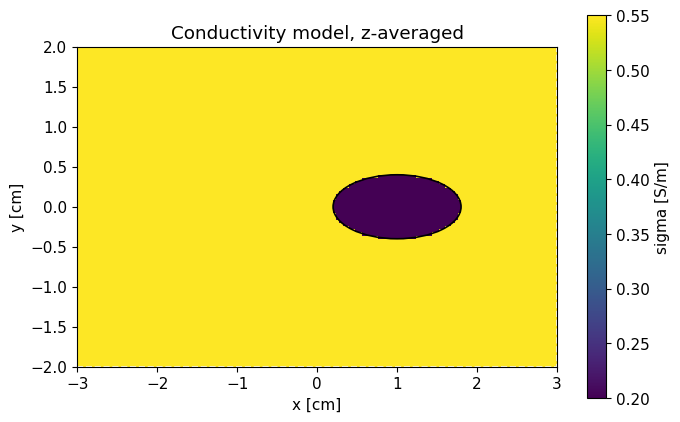


  TensorMesh: 45,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    150         -0.03          0.03      0.00      0.00    1.00
   y    100         -0.02          0.02      0.00      0.00    1.00
   z      3         -0.01         -0.00      0.00      0.00    1.00


mesh shape: (150, 100, 3) n_cells: 45000
origin [m]: [-0.03   -0.02   -0.0055]
cell widths [m]: 0.0004 0.0004 0.0003333333333333333
sample cells: 45000
scar cells: 1896
conducting cells: 45000
sigma with scar [S/m]: [0.2  0.55]
healthy sigma [S/m]: [0.55]


In [24]:
mesh = build_mesh(geometry)
model = make_model(mesh, geometry, props, scar=True)
model0 = make_model(mesh, geometry, props, scar=False)

sigma = model["sigma"]
sigma0 = model0["sigma"]
sample_mask = model["sample"]
scar_mask = model["scar"]
conductor = model["conductor"]

X_mesh, Y_mesh, sigma_xy = xy_grid(mesh, sigma)
plot_map(
    X_mesh,
    Y_mesh,
    sigma_xy,
    title="Conductivity model, z-averaged",
    label="sigma [S/m]",
    cmap="viridis",
)

print(mesh)
print("mesh shape:", mesh.shape_cells, "n_cells:", mesh.n_cells)
print("origin [m]:", mesh.origin)
print("cell widths [m]:", mesh.h[0][0], mesh.h[1][0], mesh.h[2][0])
print("sample cells:", int(sample_mask.sum()))
print("scar cells:", int(scar_mask.sum()))
print("conducting cells:", int(conductor.sum()))
print("sigma with scar [S/m]:", np.unique(sigma[conductor]))
print("healthy sigma [S/m]:", np.unique(sigma0[model0["conductor"]]))


## 3D geometry view

This plot shows the full mesh box, the conducting sample, the individual sample z-layers, and scar cells. It is useful when changing `SAMPLE_Z` or adding air cells with `AIR_X`, `AIR_Y`, and `AIR_Z`.


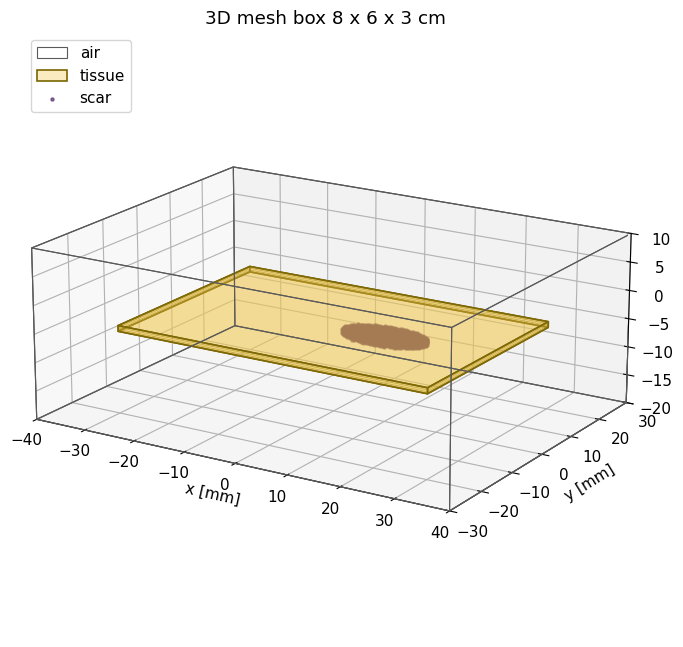

display mesh box [cm]: [8. 6. 3.]
sample requested thickness [mm]: 1.0
sample plotted thickness [mm]: 1.0
z cell width [mm]: 0.3333333333333333
sample z layers: 3
sample z bounds [mm]: [-5.5 -4.5]


In [25]:
# 3D geometry plot: true-scale mesh, sample slice, and scar cells.
# Uses mm on all axes so a 1 mm tissue really looks like a thin slice.
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

Z_EXAGGERATION = 1.0   # keep 1.0 for true geometry
SHOW_LAYER_LINES = True
SHOW_SCAR_POINTS = True

# Outer visualization box: the intended 3D mesh/air domain.
# This is drawn as an 8 x 6 x 3 cm rectangle while keeping the tissue/scar geometry as is.
DISPLAY_MESH_BOX_CM = np.array([8.0, 6.0, 3.0], dtype=float)
DISPLAY_MESH_CENTER_M = SAMPLE_CENTER.copy()


def box_faces(bounds):
    x0, x1, y0, y1, z0, z1 = bounds
    return [
        [(x0, y0, z0), (x1, y0, z0), (x1, y1, z0), (x0, y1, z0)],
        [(x0, y0, z1), (x1, y0, z1), (x1, y1, z1), (x0, y1, z1)],
        [(x0, y0, z0), (x1, y0, z0), (x1, y0, z1), (x0, y0, z1)],
        [(x0, y1, z0), (x1, y1, z0), (x1, y1, z1), (x0, y1, z1)],
        [(x0, y0, z0), (x0, y1, z0), (x0, y1, z1), (x0, y0, z1)],
        [(x1, y0, z0), (x1, y1, z0), (x1, y1, z1), (x1, y0, z1)],
    ]


def add_box(ax, bounds_m, *, color, edgecolor, alpha, label, linewidth=1.0):
    # Convert all coordinates to mm. No mixed cm/mm scaling.
    faces_mm = [
        [(x * 1000.0, y * 1000.0, z * 1000.0) for x, y, z in face]
        for face in box_faces(bounds_m)
    ]
    poly = Poly3DCollection(
        faces_mm,
        facecolors=color,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=alpha,
        label=label,
    )
    ax.add_collection3d(poly)
    return poly


def bounds_from_mask(mask):
    centers = mesh.cell_centers[np.asarray(mask, dtype=bool)]
    if centers.size == 0:
        return None
    hx, hy, hz = float(mesh.h[0][0]), float(mesh.h[1][0]), float(mesh.h[2][0])
    return (
        centers[:, 0].min() - 0.5 * hx,
        centers[:, 0].max() + 0.5 * hx,
        centers[:, 1].min() - 0.5 * hy,
        centers[:, 1].max() + 0.5 * hy,
        centers[:, 2].min() - 0.5 * hz,
        centers[:, 2].max() + 0.5 * hz,
    )


display_size_m = DISPLAY_MESH_BOX_CM / 100.0
mesh_bounds = (
    DISPLAY_MESH_CENTER_M[0] - 0.5 * display_size_m[0],
    DISPLAY_MESH_CENTER_M[0] + 0.5 * display_size_m[0],
    DISPLAY_MESH_CENTER_M[1] - 0.5 * display_size_m[1],
    DISPLAY_MESH_CENTER_M[1] + 0.5 * display_size_m[1],
    DISPLAY_MESH_CENTER_M[2] - 0.5 * display_size_m[2],
    DISPLAY_MESH_CENTER_M[2] + 0.5 * display_size_m[2],
)
sample_bounds = bounds_from_mask(sample_mask)

fig = plt.figure(figsize=(9.0, 6.6))
ax = fig.add_subplot(111, projection='3d')

# The full mesh box is just a faint outline. If there is no air, it overlaps the sample.
add_box(ax, mesh_bounds, color='white', edgecolor='0.35', alpha=0.015, label='air', linewidth=0.8)

if sample_bounds is not None:
    add_box(ax, sample_bounds, color='#f2c94c', edgecolor='#7a6500', alpha=0.35, label='tissue', linewidth=1.2)


# Optional layer interfaces. For a 1 mm tissue with 3 z cells, this shows 3 numerical layers
# without making the sample visually thick.
if SHOW_LAYER_LINES and sample_bounds is not None:
    x0, x1, y0, y1, z0, z1 = sample_bounds
    z_edges = np.unique(np.round(mesh.nodes_z, 14))
    z_edges = z_edges[(z_edges >= z0 - 1e-14) & (z_edges <= z1 + 1e-14)]
    for z in z_edges:
        ax.plot(
            [x0*1000, x1*1000, x1*1000, x0*1000, x0*1000],
            [y0*1000, y0*1000, y1*1000, y1*1000, y0*1000],
            [z*1000] * 5,
            color='#8a6f00',
            linewidth=0.8,
            alpha=0.75,
        )

if SHOW_SCAR_POINTS:
    scar_centers = mesh.cell_centers[scar_mask]
    if scar_centers.shape[0] > 0:
        max_points = 2500
        stride = max(1, int(np.ceil(scar_centers.shape[0] / max_points)))
        scar_plot = scar_centers[::stride]
        ax.scatter(
            scar_plot[:, 0] * 1000.0,
            scar_plot[:, 1] * 1000.0,
            scar_plot[:, 2] * 1000.0,
            s=5,
            c='#3b0a57',
            alpha=0.55,
            depthshade=False,
            label='scar',
        )
else:
    scar_centers = mesh.cell_centers[scar_mask]

ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_zlabel('z [mm]')
ax.set_title('3D mesh box 8 x 6 x 3 cm')

ax.set_xlim(mesh_bounds[0] * 1000.0, mesh_bounds[1] * 1000.0)
ax.set_ylim(mesh_bounds[2] * 1000.0, mesh_bounds[3] * 1000.0)
ax.set_zlim(mesh_bounds[4] * 1000.0, mesh_bounds[5] * 1000.0)

x_range = (mesh_bounds[1] - mesh_bounds[0]) * 1000.0
y_range = (mesh_bounds[3] - mesh_bounds[2]) * 1000.0
z_range = max((mesh_bounds[5] - mesh_bounds[4]) * 1000.0, 1e-9)
ax.set_box_aspect((x_range, y_range, z_range * Z_EXAGGERATION))

ax.view_init(elev=18, azim=-58)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('display mesh box [cm]:', DISPLAY_MESH_BOX_CM)
print('sample requested thickness [mm]:', SAMPLE_Z * 1000.0)
print('sample plotted thickness [mm]:', geometry['sample_size'][2] * 1000.0)
print('z cell width [mm]:', DZ * 1000.0)
print('sample z layers:', geometry['sample_shape'][2])
print('sample z bounds [mm]:', np.array(sample_bounds[4:6]) * 1000.0)


## Excitation coil and vector potential

The finite circular coil is discretized into straight midpoint segments:

$$A_0(r) \approx {\mu_0 I \over 4\pi}\sum_k {\Delta l_k \over |r-r_k|}.$$

Then the inductive driving field is

$$E_{drive} = -i\omega A_0.$$


In [26]:
def loop_segments(radius_m: float, center_xyz_m, n_segments: int):
    center_xyz_m = np.asarray(center_xyz_m, dtype=float)
    theta = 2.0 * np.pi * (np.arange(n_segments) + 0.5) / n_segments
    dtheta = 2.0 * np.pi / n_segments
    segment_xyz_m = np.column_stack([
        center_xyz_m[0] + radius_m * np.cos(theta),
        center_xyz_m[1] + radius_m * np.sin(theta),
        np.full(n_segments, center_xyz_m[2]),
    ])
    segment_dl_m = np.column_stack([
        -radius_m * np.sin(theta) * dtheta,
         radius_m * np.cos(theta) * dtheta,
         np.zeros(n_segments),
    ])
    return segment_xyz_m, segment_dl_m


def loop_A(observation_xyz_m, segment_xyz_m, segment_dl_m, current_A: float, *, chunk_size=4096, mu0=MU0):
    observation_xyz_m = np.asarray(observation_xyz_m, dtype=float)
    was_1d = observation_xyz_m.ndim == 1
    observation_xyz_m = np.atleast_2d(observation_xyz_m)

    A = np.zeros_like(observation_xyz_m, dtype=float)
    prefactor = mu0 * current_A / (4.0 * np.pi)

    for start in range(0, observation_xyz_m.shape[0], chunk_size):
        stop = min(start + chunk_size, observation_xyz_m.shape[0])
        r_minus_rprime = observation_xyz_m[start:stop, None, :] - segment_xyz_m[None, :, :]
        distance_m = np.linalg.norm(r_minus_rprime, axis=2)
        if np.any(distance_m == 0.0):
            raise ValueError("An observation point lies on a coil segment; A0 is singular there.")
        A[start:stop] = prefactor * np.sum(
            segment_dl_m[None, :, :] / distance_m[:, :, None],
            axis=1,
        )

    return A[0] if was_1d else A


def loop_B(observation_xyz_m, segment_xyz_m, segment_dl_m, current_A: float, *, chunk_size=4096, mu0=MU0):
    observation_xyz_m = np.asarray(observation_xyz_m, dtype=float)
    was_1d = observation_xyz_m.ndim == 1
    observation_xyz_m = np.atleast_2d(observation_xyz_m)

    magnetic_flux_density_T = np.zeros_like(observation_xyz_m, dtype=float)
    prefactor = mu0 * current_A / (4.0 * np.pi)

    for start in range(0, observation_xyz_m.shape[0], chunk_size):
        stop = min(start + chunk_size, observation_xyz_m.shape[0])
        r_minus_rprime = observation_xyz_m[start:stop, None, :] - segment_xyz_m[None, :, :]
        distance_m = np.linalg.norm(r_minus_rprime, axis=2)
        if np.any(distance_m == 0.0):
            raise ValueError("An observation point lies on a coil segment; B is singular there.")
        magnetic_flux_density_T[start:stop] = prefactor * np.sum(
            np.cross(segment_dl_m[None, :, :], r_minus_rprime) / distance_m[:, :, None] ** 3,
            axis=1,
        )

    return magnetic_flux_density_T[0] if was_1d else magnetic_flux_density_T


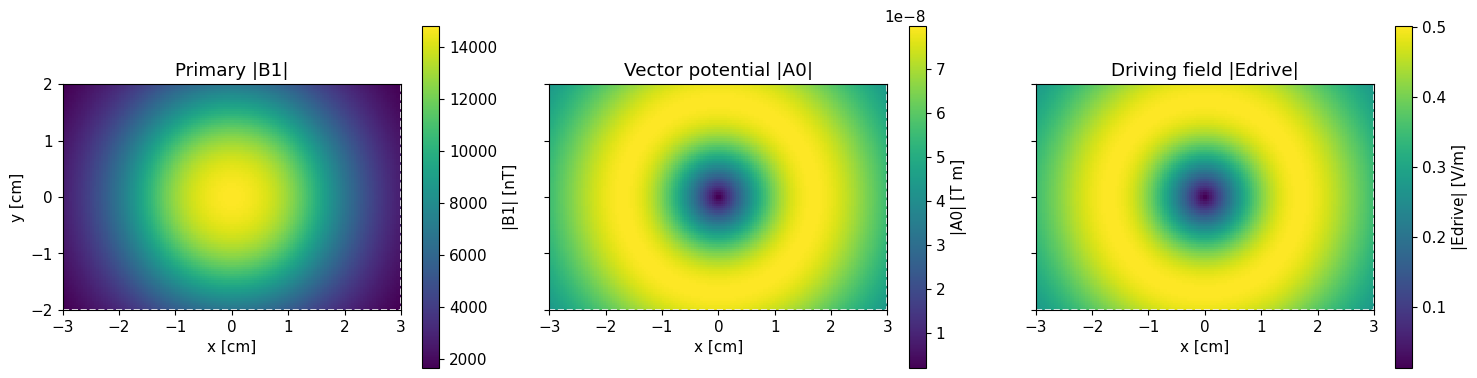

reference point [m]: [ 0.     0.    -0.005]
primary B at reference [T]: [ 6.66133815e-22 -1.17614252e-22  1.48096098e-05]
primary Bz at reference [nT]: 14809.609793861217
A0 component min [T m]: [-8.22519943e-08 -8.22519943e-08  0.00000000e+00]
A0 component max [T m]: [8.22519943e-08 8.22519943e-08 0.00000000e+00]
max |Edrive| [V/m]: 0.5169045788064341


In [27]:
coil_segment_xyz_m, coil_segment_dl_m = loop_segments(
    coil_radius,
    coil_center,
    coil_segments,
)

A0 = loop_A(
    mesh.cell_centers,
    coil_segment_xyz_m,
    coil_segment_dl_m,
    coil_current,
    chunk_size=chunk,
)

B1 = loop_B(
    mesh.cell_centers,
    coil_segment_xyz_m,
    coil_segment_dl_m,
    coil_current,
    chunk_size=chunk,
)
B1_ref = loop_B(
    ref_xyz,
    coil_segment_xyz_m,
    coil_segment_dl_m,
    coil_current,
    chunk_size=1,
)

E0 = -1j * omega * A0

A0_norm = np.linalg.norm(A0, axis=1)
Edrive_norm = np.linalg.norm(E0, axis=1)
B1_norm = np.linalg.norm(B1, axis=1)
_, _, A0_grid = xy_grid(mesh, A0_norm)
_, _, Edrive_grid = xy_grid(mesh, Edrive_norm)
_, _, B1_grid = xy_grid(mesh, B1_norm)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.5), sharex=True, sharey=True)
for ax, values, title, label in [
    (axes[0], B1_grid * 1e9, "Primary |B1|", "|B1| [nT]"),
    (axes[1], A0_grid, "Vector potential |A0|", "|A0| [T m]"),
    (axes[2], Edrive_grid, "Driving field |Edrive|", "|Edrive| [V/m]"),
]:
    im = ax.pcolormesh(X_mesh * 100.0, Y_mesh * 100.0, values, shading="auto", cmap="viridis")
    add_outlines(ax, geometry, scar=False)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x [cm]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=label, shrink=0.82)
axes[0].set_ylabel("y [cm]")
plt.tight_layout()
plt.show()

print("reference point [m]:", ref_xyz)
print("primary B at reference [T]:", B1_ref)
print("primary Bz at reference [nT]:", B1_ref[2] * 1e9)
print("A0 component min [T m]:", A0.min(axis=0))
print("A0 component max [T m]:", A0.max(axis=0))
print("max |Edrive| [V/m]:", float(Edrive_norm.max()))


## Scalar potential for closed eddy current

The scalar potential `phi` is solved so the volume current density is closed inside the tissue:

$$J = \sigma(-i\omega A_0 - \nabla\phi).$$

The sparse solve enforces current balance through the finite-volume neighbour equations. After solving `phi`, the electric field is reconstructed at cell centres, and the pickup field is computed from cell-centred volume currents only.


In [28]:
def axis_spacing_and_area(mesh: TensorMesh, axis: int):
    hx = float(mesh.h[0][0])
    hy = float(mesh.h[1][0])
    hz = float(mesh.h[2][0])
    if axis == 0:
        return hx, hy * hz
    if axis == 1:
        return hy, hx * hz
    if axis == 2:
        return hz, hx * hy
    raise ValueError("axis must be 0, 1, or 2")


def interface_conductivity(sigma_p, sigma_q, method="harmonic"):
    sigma_p = complex(sigma_p)
    sigma_q = complex(sigma_q)
    if method == "arithmetic":
        return 0.5 * (sigma_p + sigma_q)
    if method == "harmonic":
        if sigma_p + sigma_q == 0.0:
            return 0.0
        return 2.0 * sigma_p * sigma_q / (sigma_p + sigma_q)
    raise ValueError("method must be 'harmonic' or 'arithmetic'")


def conductor_neighbor_pairs(mesh: TensorMesh, conductor):
    conductor = np.asarray(conductor, dtype=bool)
    full_index_grid = np.arange(mesh.n_cells).reshape(mesh.shape_cells, order="F")
    pairs = []
    for axis in range(3):
        slicer_p = [slice(None), slice(None), slice(None)]
        slicer_q = [slice(None), slice(None), slice(None)]
        slicer_p[axis] = slice(0, -1)
        slicer_q[axis] = slice(1, None)

        p_full = full_index_grid[tuple(slicer_p)].ravel(order="F")
        q_full = full_index_grid[tuple(slicer_q)].ravel(order="F")
        both_conducting = conductor[p_full] & conductor[q_full]
        pairs.append((axis, p_full[both_conducting], q_full[both_conducting]))
    return pairs


def solve_phi(
    mesh: TensorMesh,
    sigma_in,
    E0,
    conductor=None,
    *,
    interface_sigma_method="harmonic",
):
    sigma_in = np.asarray(sigma_in, dtype=complex)
    E0 = np.asarray(E0, dtype=complex)
    if conductor is None:
        conductor = np.abs(sigma_in) > 0.0
    conductor = np.asarray(conductor, dtype=bool)

    conductor_full_indices = np.flatnonzero(conductor)
    n_conductor = conductor_full_indices.size
    if n_conductor == 0:
        raise ValueError("No conducting cells were found.")

    full_to_conductor = -np.ones(mesh.n_cells, dtype=int)
    full_to_conductor[conductor_full_indices] = np.arange(n_conductor)

    rows, cols, data = [], [], []
    rhs = np.zeros(n_conductor, dtype=complex)
    graph_row, graph_col = [], []
    pairs = conductor_neighbor_pairs(mesh, conductor)

    for axis, p_full_values, q_full_values in pairs:
        h_axis_m, area_m2 = axis_spacing_and_area(mesh, axis)
        for p_full, q_full in zip(p_full_values, q_full_values):
            p = full_to_conductor[p_full]
            q = full_to_conductor[q_full]
            sigma_interface = interface_conductivity(
                sigma_in[p_full],
                sigma_in[q_full],
                method=interface_sigma_method,
            )
            conductance = sigma_interface * area_m2 / h_axis_m
            drive_component = 0.5 * (
                E0[p_full, axis] +
                E0[q_full, axis]
            )
            source_current = sigma_interface * area_m2 * drive_component

            rows.extend([p, p, q, q])
            cols.extend([p, q, q, p])
            data.extend([conductance, -conductance, conductance, -conductance])
            rhs[p] += -source_current
            rhs[q] += source_current

            graph_row.extend([p, q])
            graph_col.extend([q, p])

    matrix = sp.coo_matrix((data, (rows, cols)), shape=(n_conductor, n_conductor)).tolil()

    if graph_row:
        graph = sp.coo_matrix(
            (np.ones(len(graph_row)), (graph_row, graph_col)),
            shape=(n_conductor, n_conductor),
        ).tocsr()
        n_components, component_id = connected_components(graph, directed=False, return_labels=True)
    else:
        n_components = n_conductor
        component_id = np.arange(n_conductor)

    for component in range(n_components):
        gauge_row = int(np.flatnonzero(component_id == component)[0])
        matrix[gauge_row, :] = 0.0
        matrix[gauge_row, gauge_row] = 1.0
        rhs[gauge_row] = 0.0

    phi_conductor_V = spla.spsolve(matrix.tocsr(), rhs)
    phi_full_V = np.zeros(mesh.n_cells, dtype=complex)
    phi_full_V[conductor_full_indices] = phi_conductor_V

    return {
        "phi_conductor_V": phi_conductor_V,
        "phi_full_V": phi_full_V,
        "conductor_full_indices": conductor_full_indices,
        "full_to_conductor": full_to_conductor,
        "component_id": component_id,
        "n_conductor_components": int(n_components),
        "neighbor_pairs": pairs,
        "interface_sigma_method": interface_sigma_method,
    }


def reconstruct_J(
    mesh: TensorMesh,
    sigma_in,
    E0,
    potential_solution: dict,
):
    sigma_in = np.asarray(sigma_in, dtype=complex)
    E0 = np.asarray(E0, dtype=complex)

    conductor_full_indices = potential_solution["conductor_full_indices"]
    full_to_conductor = potential_solution["full_to_conductor"]
    phi = potential_solution["phi_conductor_V"]
    pairs = potential_solution["neighbor_pairs"]
    interface_sigma_method = potential_solution["interface_sigma_method"]

    n_conductor = conductor_full_indices.size
    E_cond = np.zeros((n_conductor, 3), dtype=complex)
    component_counts = np.zeros((n_conductor, 3), dtype=float)
    balance_A = np.zeros(n_conductor, dtype=complex)

    for axis, p_full_values, q_full_values in pairs:
        h_axis_m, area_m2 = axis_spacing_and_area(mesh, axis)
        for p_full, q_full in zip(p_full_values, q_full_values):
            p = full_to_conductor[p_full]
            q = full_to_conductor[q_full]
            sigma_interface = interface_conductivity(
                sigma_in[p_full],
                sigma_in[q_full],
                method=interface_sigma_method,
            )
            drive_component = 0.5 * (
                E0[p_full, axis] +
                E0[q_full, axis]
            )
            grad_phi_component = (phi[q] - phi[p]) / h_axis_m
            total_component = drive_component - grad_phi_component
            interface_current_A = sigma_interface * area_m2 * total_component

            E_cond[p, axis] += total_component
            E_cond[q, axis] += total_component
            component_counts[p, axis] += 1.0
            component_counts[q, axis] += 1.0

            balance_A[p] += interface_current_A
            balance_A[q] -= interface_current_A

    nonzero = component_counts > 0.0
    E_cond[nonzero] /= component_counts[nonzero]

    J_cond = (
        sigma_in[conductor_full_indices, None] * E_cond
    )

    E = np.zeros((mesh.n_cells, 3), dtype=complex)
    J = np.zeros((mesh.n_cells, 3), dtype=complex)
    E[conductor_full_indices] = E_cond
    J[conductor_full_indices] = J_cond

    return {
        "E": E,
        "J": J,
        "component_counts": component_counts,
        "balance_A": balance_A,
    }


def solve_current(
    mesh: TensorMesh,
    sigma_in,
    A0_in,
    omega: float,
    conductor=None,
    *,
    interface_sigma_method="harmonic",
):
    E0 = -1j * omega * np.asarray(A0_in, dtype=complex)
    potential_solution = solve_phi(
        mesh,
        sigma_in,
        E0,
        conductor=conductor,
        interface_sigma_method=interface_sigma_method,
    )
    current_solution = reconstruct_J(
        mesh,
        sigma_in,
        E0,
        potential_solution,
    )
    return {**potential_solution, **current_solution, "E0": E0}


## Volume-current Biot-Savart pickup field

For pickup point `r_j` and source voxel `r_i`, this is the discrete version used here:

$$B_{sec,z}(r_j) \approx {\mu_0 \over 4\pi}\sum_i {J_{x,i}(y_j-y_i) - J_{y,i}(x_j-x_i) \over [(x_j-x_i)^2+(y_j-y_i)^2+(z_j-z_i)^2]^{3/2}}\Delta V_i.$$

This is the only magnetic-field evaluation used below.


In [29]:
def volume_bz(
    observation_xyz_m,
    source_xyz_m,
    J_in,
    source_volume_m3,
    *,
    observation_chunk=128,
    source_chunk=4096,
    mu0=MU0,
):
    observation_xyz_m = np.asarray(observation_xyz_m, dtype=float)
    was_1d = observation_xyz_m.ndim == 1
    observation_xyz_m = np.atleast_2d(observation_xyz_m)
    source_xyz_m = np.asarray(source_xyz_m, dtype=float)
    J_in = np.asarray(J_in, dtype=complex)
    source_volume_m3 = np.asarray(source_volume_m3, dtype=float)

    Bz_T = np.zeros(observation_xyz_m.shape[0], dtype=complex)
    prefactor = mu0 / (4.0 * np.pi)

    if source_xyz_m.shape[0] == 0:
        return Bz_T[0] if was_1d else Bz_T

    for obs_start in range(0, observation_xyz_m.shape[0], observation_chunk):
        obs_stop = min(obs_start + observation_chunk, observation_xyz_m.shape[0])
        obs = observation_xyz_m[obs_start:obs_stop]
        Bz_chunk = np.zeros(obs.shape[0], dtype=complex)

        for src_start in range(0, source_xyz_m.shape[0], source_chunk):
            src_stop = min(src_start + source_chunk, source_xyz_m.shape[0])
            src = source_xyz_m[src_start:src_stop]
            J = J_in[src_start:src_stop]
            volume = source_volume_m3[src_start:src_stop]

            R = obs[:, None, :] - src[None, :, :]
            R2 = np.sum(R * R, axis=2)
            if np.any(R2 == 0.0):
                raise ValueError("Observation point coincides with a source cell centre; Biot-Savart is singular.")
            R3 = R2 * np.sqrt(R2)

            numerator_z = J[None, :, 0] * R[:, :, 1] - J[None, :, 1] * R[:, :, 0]
            Bz_chunk += prefactor * np.sum(numerator_z / R3 * volume[None, :], axis=1)

        Bz_T[obs_start:obs_stop] = Bz_chunk

    return Bz_T[0] if was_1d else Bz_T


def bz_from_J(mesh: TensorMesh, observation_xyz_m, J, source_mask):
    source_mask = np.asarray(source_mask, dtype=bool)
    return volume_bz(
        observation_xyz_m,
        mesh.cell_centers[source_mask],
        np.asarray(J)[source_mask],
        mesh.cell_volumes[source_mask],
    )


def scan_grid(x_limits_m, y_limits_m, nx: int, ny: int, z_m: float):
    x = np.linspace(float(x_limits_m[0]), float(x_limits_m[1]), nx)
    y = np.linspace(float(y_limits_m[0]), float(y_limits_m[1]), ny)
    X, Y = np.meshgrid(x, y)
    locations = np.column_stack([X.ravel(), Y.ravel(), np.full(X.size, z_m)])
    return locations, X, Y


def run_forward(
    mesh: TensorMesh,
    sigma_in,
    receiver_xyz_m,
    A0_in,
    omega: float,
    conductor=None,
    *,
    interface_sigma_method="harmonic",
):
    if conductor is None:
        conductor = np.asarray(sigma_in) > 0.0
    conductor = np.asarray(conductor, dtype=bool)
    current_solution = solve_current(
        mesh,
        sigma_in,
        A0_in,
        omega,
        conductor=conductor,
        interface_sigma_method=interface_sigma_method,
    )
    Bz_T = bz_from_J(
        mesh,
        receiver_xyz_m,
        current_solution["J"],
        conductor,
    )
    return {
        **current_solution,
        "receiver_xyz_m": np.asarray(receiver_xyz_m, dtype=float),
        "Bz_T": Bz_T,
        "Bz_nT": Bz_T * 1e9,
        "Bz_real_nT": np.real(Bz_T * 1e9),
        "Bz_imag_nT": np.imag(Bz_T * 1e9),
        "Bz_abs_nT": np.abs(Bz_T * 1e9),
        "conductor": conductor,
    }


## Point-pickup scan

This is the no-averaging point scan at the pickup height. It uses the scar conductivity model.


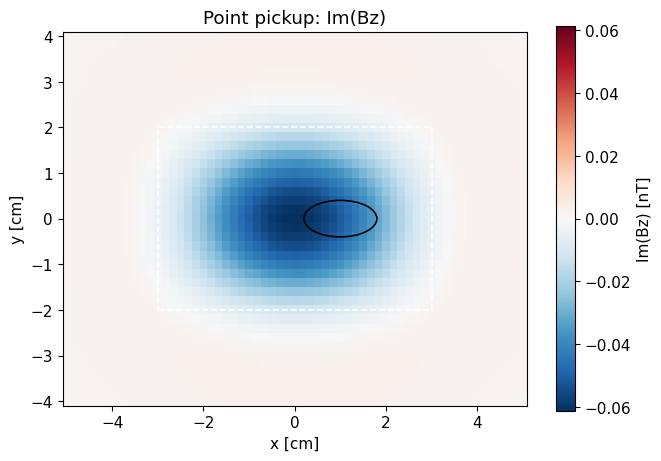

point scan shape: (41, 61)
point Im(Bz) min/max [nT]: -0.0613175764200921 0.003287440227983168
max current-balance residual [A]: 2.553107694799581e-18


,x_cm,y_cm,z_m,Bz_real_nT,Bz_imag_nT,Bz_abs_nT
0,-5.000000,-4.0,0.01,0.0,0.001358,0.001358
1,-4.833333,-4.0,0.01,0.0,0.001427,0.001427
2,-4.666667,-4.0,0.01,0.0,0.001498,0.001498
3,-4.500000,-4.0,0.01,0.0,0.001571,0.001571
4,-4.333333,-4.0,0.01,0.0,0.001647,0.001647


In [30]:
point_xyz, point_X, point_Y = scan_grid(
    POINT_SCAN_X_LIMITS_M,
    POINT_SCAN_Y_LIMITS_M,
    POINT_SCAN_NX,
    POINT_SCAN_NY,
    PICKUP_Z_M,
)

v3_point = run_forward(
    mesh=mesh,
    sigma_in=sigma,
    receiver_xyz_m=point_xyz,
    A0_in=A0,
    omega=omega,
    conductor=conductor,
)

point_imag_grid = v3_point["Bz_imag_nT"].reshape(POINT_SCAN_NY, POINT_SCAN_NX)

fig, ax = plt.subplots(figsize=(6.8, 5.1))
vmax = max(float(np.max(np.abs(point_imag_grid))), 1e-30)
im = ax.pcolormesh(
    point_X * 100.0,
    point_Y * 100.0,
    point_imag_grid,
    shading="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
add_outlines(ax, geometry)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Point pickup: Im(Bz)")
fig.colorbar(im, ax=ax, label="Im(Bz) [nT]", shrink=0.84)
plt.tight_layout()
plt.show()

point_scan_df = pd.DataFrame({
    "x_cm": point_X.ravel() * 100.0,
    "y_cm": point_Y.ravel() * 100.0,
    "z_m": point_xyz[:, 2],
    "Bz_real_nT": v3_point["Bz_real_nT"],
    "Bz_imag_nT": v3_point["Bz_imag_nT"],
    "Bz_abs_nT": v3_point["Bz_abs_nT"],
})

print("point scan shape:", point_imag_grid.shape)
print("point Im(Bz) min/max [nT]:", float(point_imag_grid.min()), float(point_imag_grid.max()))
print("max current-balance residual [A]:", float(np.max(np.abs(v3_point["balance_A"]))))
point_scan_df.head()


### Solved electric field

The earlier `Driving field |Edrive|` panel shows only `-i omega A0`. The forward model actually uses the closed-current field

$$E = -i\omega A_0 - \nabla\phi,$$

which is the field used in `J = sigma E`. This plot shows that solved total field on the middle sample layer.


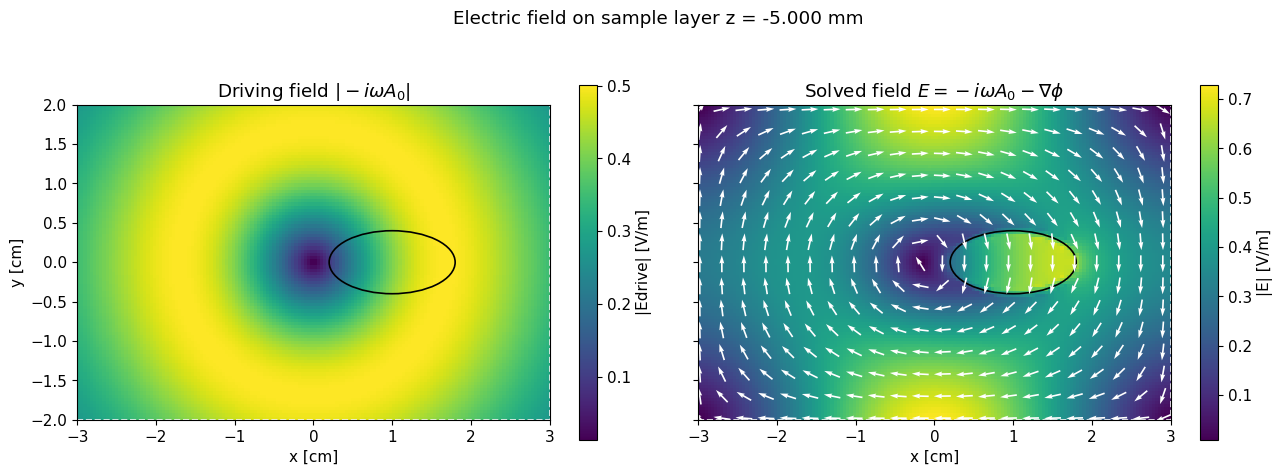

middle layer z [mm]: -5.0
max |Edrive| [V/m]: 0.5011805502483957
max |E solved| [V/m]: 0.7288033003965371
max |E - Edrive| [V/m]: 0.26652088309209365


In [31]:
# Plot the solved closed electric field E = -i omega A0 - grad(phi).
# This is the field actually used in J = sigma E.

def layer_grid_from_values(mask, values):
    centers = mesh.cell_centers[mask]
    x = centers[:, 0]
    y = centers[:, 1]
    xu = np.unique(np.round(x, 12))
    yu = np.unique(np.round(y, 12))
    grid = np.full((yu.size, xu.size), np.nan, dtype=float)
    ix = np.searchsorted(xu, np.round(x, 12))
    iy = np.searchsorted(yu, np.round(y, 12))
    grid[iy, ix] = values
    X, Y = np.meshgrid(xu, yu)
    return X, Y, grid


E_total = v3_point["E"]
E_drive = v3_point["E0"]

sample_z = np.unique(np.round(mesh.cell_centers[sample_mask, 2], 12))
z_mid = sample_z[np.argmin(np.abs(sample_z - geometry["sample_center"][2]))]
layer = sample_mask & np.isclose(mesh.cell_centers[:, 2], z_mid)

E_layer = E_total[layer]
Edrive_layer = E_drive[layer]

E_mag = np.linalg.norm(E_layer, axis=1)
Edrive_mag = np.linalg.norm(Edrive_layer, axis=1)

# A0 is real here, so -i omega A0 and the solved correction are mostly imaginary.
# Use the dominant phasor component for arrows.
arrow_xy = np.imag(E_layer[:, :2])
if np.nanmax(np.linalg.norm(arrow_xy, axis=1)) < 1e-20:
    arrow_xy = np.real(E_layer[:, :2])

arrow_norm = np.linalg.norm(arrow_xy, axis=1)
arrow_unit = np.zeros_like(arrow_xy, dtype=float)
nonzero = arrow_norm > 0
arrow_unit[nonzero] = arrow_xy[nonzero] / arrow_norm[nonzero, None]

X_E, Y_E, E_grid = layer_grid_from_values(layer, E_mag)
_, _, Edrive_grid_layer = layer_grid_from_values(layer, Edrive_mag)
_, _, U_grid = layer_grid_from_values(layer, arrow_unit[:, 0])
_, _, V_grid = layer_grid_from_values(layer, arrow_unit[:, 1])

# Decimate arrows so the plot is readable.
arrow_step = max(1, int(np.ceil(max(X_E.shape) / 24)))
arrow_slice = (slice(None, None, arrow_step), slice(None, None, arrow_step))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.9), sharex=True, sharey=True)

im0 = axes[0].pcolormesh(
    X_E * 100.0,
    Y_E * 100.0,
    Edrive_grid_layer,
    shading="auto",
    cmap="viridis",
)
add_outlines(axes[0], geometry)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title(r"Driving field $|-i\omega A_0|$")
axes[0].set_xlabel("x [cm]")
axes[0].set_ylabel("y [cm]")
fig.colorbar(im0, ax=axes[0], label="|Edrive| [V/m]", shrink=0.84)

im1 = axes[1].pcolormesh(
    X_E * 100.0,
    Y_E * 100.0,
    E_grid,
    shading="auto",
    cmap="viridis",
)
add_outlines(axes[1], geometry)
axes[1].quiver(
    X_E[arrow_slice] * 100.0,
    Y_E[arrow_slice] * 100.0,
    U_grid[arrow_slice],
    V_grid[arrow_slice],
    color="white",
    pivot="mid",
    scale=28,
    width=0.0035,
)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title(r"Solved field $E=-i\omega A_0-\nabla\phi$")
axes[1].set_xlabel("x [cm]")
fig.colorbar(im1, ax=axes[1], label="|E| [V/m]", shrink=0.84)

fig.suptitle(f"Electric field on sample layer z = {z_mid * 1000:.3f} mm")
plt.tight_layout()
plt.show()

print("middle layer z [mm]:", z_mid * 1000.0)
print("max |Edrive| [V/m]:", float(np.nanmax(Edrive_mag)))
print("max |E solved| [V/m]:", float(np.nanmax(E_mag)))
print("max |E - Edrive| [V/m]:", float(np.nanmax(np.linalg.norm(E_layer - Edrive_layer, axis=1))))


## Receiving-disk averaged scan

The pickup coil is represented by equal-area sample points over a disk. For each pickup centre, the notebook evaluates the same volume-current Biot-Savart field at all disk samples and averages them.


In [32]:
def disk_offsets(diameter_m: float, n_points: int):
    radius_m = 0.5 * float(diameter_m)
    if n_points < 1:
        raise ValueError("n_points must be positive")
    if n_points == 1:
        return np.zeros((1, 2), dtype=float)

    golden_angle = np.pi * (3.0 - np.sqrt(5.0))
    i = np.arange(n_points, dtype=float)
    r = radius_m * np.sqrt((i + 0.5) / n_points)
    theta = i * golden_angle
    return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


def receiver_grid(x_limits_m, y_limits_m, nx: int, ny: int, z_m: float):
    centers, X, Y = scan_grid(x_limits_m, y_limits_m, nx, ny, z_m)
    return centers, X, Y


def disk_sample_locations_for_centers(center_xyz_m, disk_offsets_xy_m):
    center_xyz_m = np.asarray(center_xyz_m, dtype=float)
    disk_offsets_xy_m = np.asarray(disk_offsets_xy_m, dtype=float)
    locs = np.repeat(center_xyz_m, disk_offsets_xy_m.shape[0], axis=0)
    tiled_offsets = np.tile(disk_offsets_xy_m, (center_xyz_m.shape[0], 1))
    locs[:, 0] += tiled_offsets[:, 0]
    locs[:, 1] += tiled_offsets[:, 1]
    return locs


def disk_average_bz(
    mesh: TensorMesh,
    center_xyz_m,
    disk_offsets_xy_m,
    J,
    source_mask,
    *,
    center_chunk=4,
):
    center_xyz_m = np.asarray(center_xyz_m, dtype=float)
    disk_offsets_xy_m = np.asarray(disk_offsets_xy_m, dtype=float)
    source_mask = np.asarray(source_mask, dtype=bool)

    averaged_Bz_T = np.zeros(center_xyz_m.shape[0], dtype=complex)
    n_disk = disk_offsets_xy_m.shape[0]

    for start in range(0, center_xyz_m.shape[0], center_chunk):
        stop = min(start + center_chunk, center_xyz_m.shape[0])
        sample_xyz_m = disk_sample_locations_for_centers(center_xyz_m[start:stop], disk_offsets_xy_m)
        sample_Bz_T = bz_from_J(
            mesh,
            sample_xyz_m,
            J,
            source_mask,
        )
        averaged_Bz_T[start:stop] = sample_Bz_T.reshape(stop - start, n_disk).mean(axis=1)

    return averaged_Bz_T


def solve_current_only(sigma_in):
    source_mask = np.asarray(sigma_in) > 0.0
    return solve_current(
        mesh=mesh,
        sigma_in=sigma_in,
        A0_in=A0,
        omega=omega,
        conductor=source_mask,
    )


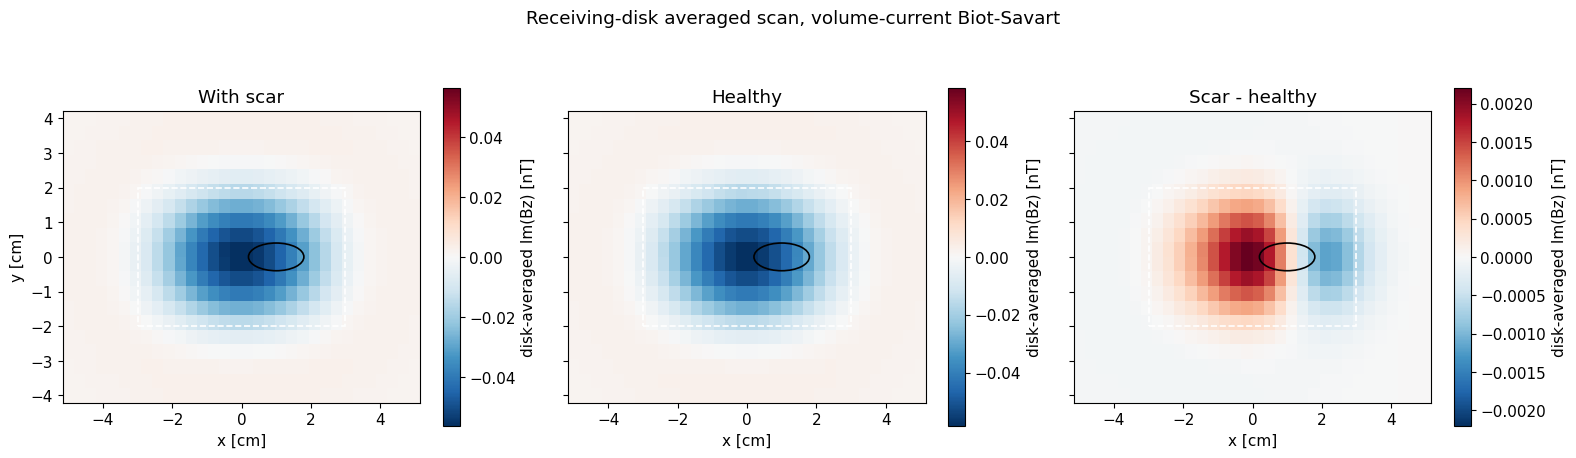

pickup grid: (20, 32) centres: 640
disk sample count: 40
scar disk Im(Bz) min/max [nT]: -0.0563383227918698 0.0030522428387979358
healthy disk Im(Bz) min/max [nT]: -0.05851300916962684 0.003104527614946649
contrast Im(Bz) min/max [nT]: -0.0011870943937962002 0.002205231494032553


In [33]:
disk_xy = disk_offsets(
    PICKUP_COIL_DIAMETER_M,
    PICKUP_DISK_SAMPLE_COUNT,
)
pickup_xyz, pickup_X, pickup_Y = receiver_grid(
    PICKUP_X_LIMITS_M,
    PICKUP_Y_LIMITS_M,
    PICKUP_GRID_NX,
    PICKUP_GRID_NY,
    PICKUP_Z_M,
)

cur0 = solve_current_only(sigma0)
cur = {
    key: v3_point[key]
    for key in [
        "E",
        "J",
        "balance_A",
    ]
}

Bz_disk = disk_average_bz(
    mesh,
    pickup_xyz,
    disk_xy,
    cur["J"],
    sigma > 0.0,
    center_chunk=PICKUP_CENTER_CHUNK,
)
Bz0_disk = disk_average_bz(
    mesh,
    pickup_xyz,
    disk_xy,
    cur0["J"],
    sigma0 > 0.0,
    center_chunk=PICKUP_CENTER_CHUNK,
)

disk_imag = np.imag(Bz_disk * 1e9)
disk0_imag = np.imag(Bz0_disk * 1e9)
contrast_imag = disk_imag - disk0_imag

disk_grid = disk_imag.reshape(PICKUP_GRID_NY, PICKUP_GRID_NX)
disk0_grid = disk0_imag.reshape(PICKUP_GRID_NY, PICKUP_GRID_NX)
contrast_grid = contrast_imag.reshape(PICKUP_GRID_NY, PICKUP_GRID_NX)

fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.8), sharex=True, sharey=True)
for ax, values, title in [
    (axes[0], disk_grid, "With scar"),
    (axes[1], disk0_grid, "Healthy"),
    (axes[2], contrast_grid, "Scar - healthy"),
]:
    vmax = max(float(np.max(np.abs(values))), 1e-30)
    im = ax.pcolormesh(pickup_X * 100.0, pickup_Y * 100.0, values, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    add_outlines(ax, geometry)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x [cm]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="disk-averaged Im(Bz) [nT]", shrink=0.82)
axes[0].set_ylabel("y [cm]")
fig.suptitle("Receiving-disk averaged scan, volume-current Biot-Savart")
plt.tight_layout()
plt.show()

print("pickup grid:", (PICKUP_GRID_NY, PICKUP_GRID_NX), "centres:", pickup_xyz.shape[0])
print("disk sample count:", disk_xy.shape[0])
print("scar disk Im(Bz) min/max [nT]:", float(disk_grid.min()), float(disk_grid.max()))
print("healthy disk Im(Bz) min/max [nT]:", float(disk0_grid.min()), float(disk0_grid.max()))
print("contrast Im(Bz) min/max [nT]:", float(contrast_grid.min()), float(contrast_grid.max()))


## Volume-current transfer matrix

The transfer matrix below maps 5 mm conductivity pixels to disk-averaged pickup response using the volume-current formula.

For speed and readability, this is a local linearized transfer matrix around the healthy closed-current solution:

$$\delta J_i \approx E_{closed,i}^{healthy}\,\delta\sigma_i.$$

Each column sets `delta sigma = 1 S/m` inside one 5 mm pixel and computes the disk-averaged `Im(Bz)` from the resulting volume current perturbation. This keeps the SVD in the same physics language as the notebook: source volume current to measured secondary field.


In [34]:
def make_pixels(mesh: TensorMesh, source_mask, pixel_size_m: float):
    source_mask = np.asarray(source_mask, dtype=bool)
    source_indices = np.flatnonzero(source_mask)
    centers = mesh.cell_centers[source_indices]
    x = centers[:, 0]
    y = centers[:, 1]

    dx = float(np.min(mesh.h[0]))
    dy = float(np.min(mesh.h[1]))
    x_edges = np.arange(x.min() - 0.5 * dx, x.max() + 0.5 * dx + pixel_size_m, pixel_size_m)
    y_edges = np.arange(y.min() - 0.5 * dy, y.max() + 0.5 * dy + pixel_size_m, pixel_size_m)

    pixel_indices = []
    pixel_centers_xy = []
    pixel_n = []

    for ix in range(len(x_edges) - 1):
        for iy in range(len(y_edges) - 1):
            local = (
                (x >= x_edges[ix]) & (x < x_edges[ix + 1]) &
                (y >= y_edges[iy]) & (y < y_edges[iy + 1])
            )
            if not np.any(local):
                continue
            full_indices = source_indices[local]
            pixel_indices.append(full_indices)
            pixel_centers_xy.append([
                0.5 * (x_edges[ix] + x_edges[ix + 1]),
                0.5 * (y_edges[iy] + y_edges[iy + 1]),
            ])
            pixel_n.append(full_indices.size)

    return {
        "pixel_indices": pixel_indices,
        "pixel_xy": np.asarray(pixel_centers_xy),
        "pixel_n": np.asarray(pixel_n, dtype=int),
        "x_edges_m": x_edges,
        "y_edges_m": y_edges,
    }


def build_T(
    mesh: TensorMesh,
    pickup_xyz,
    disk_offsets_xy_m,
    pixels: dict,
    baseline_E,
    *,
    center_chunk=16,
    progress_every=20,
):
    pixel_indices = pixels["pixel_indices"]
    n_measurements = pickup_xyz.shape[0]
    n_pixels = len(pixel_indices)
    T_nT_per_Sm = np.zeros((n_measurements, n_pixels), dtype=float)

    for j, cell_indices in enumerate(pixel_indices):
        if progress_every and ((j + 1) % progress_every == 0 or (j + 1) == n_pixels):
            print(f"transfer column {j + 1}/{n_pixels}")

        current_density_delta = np.zeros((mesh.n_cells, 3), dtype=complex)
        current_density_delta[cell_indices] = baseline_E[cell_indices]
        pixel_mask = np.zeros(mesh.n_cells, dtype=bool)
        pixel_mask[cell_indices] = True

        Bz_pixel_T = disk_average_bz(
            mesh,
            pickup_xyz,
            disk_offsets_xy_m,
            current_density_delta,
            pixel_mask,
            center_chunk=center_chunk,
        )
        T_nT_per_Sm[:, j] = np.imag(Bz_pixel_T * 1e9)

    return T_nT_per_Sm


def pixel_grid(pixel_xy, values):
    pixel_xy = np.asarray(pixel_xy)
    values = np.asarray(values)
    x_unique = np.unique(np.round(pixel_xy[:, 0], 12))
    y_unique = np.unique(np.round(pixel_xy[:, 1], 12))
    grid = np.full((y_unique.size, x_unique.size), np.nan)
    for value, (xc, yc) in zip(values, pixel_xy):
        ix = int(np.where(np.isclose(x_unique, xc))[0][0])
        iy = int(np.where(np.isclose(y_unique, yc))[0][0])
        grid[iy, ix] = value
    extent_cm = [x_unique.min() * 100.0, x_unique.max() * 100.0, y_unique.min() * 100.0, y_unique.max() * 100.0]
    return grid, extent_cm, x_unique, y_unique


transfer column 20/96
transfer column 40/96
transfer column 60/96
transfer column 80/96
transfer column 96/96


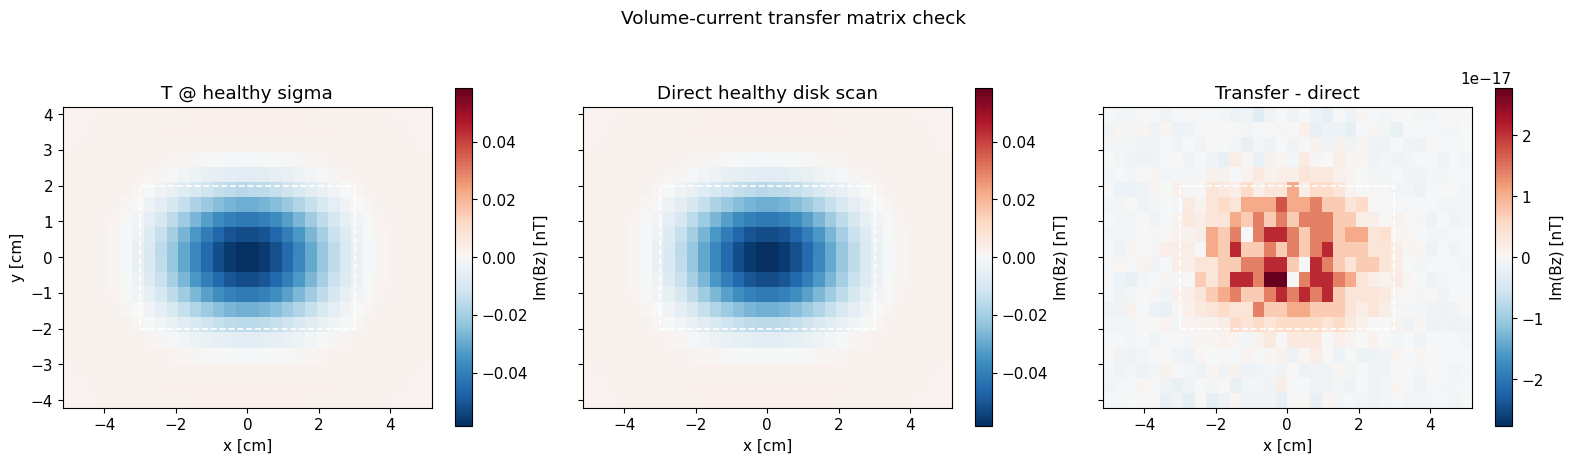

T shape [measurements x source pixels]: (640, 96)
source pixels: 96
cells per pixel min/max: 432 507
direct healthy min/max [nT]: -0.05851300916962684 0.003104527614946649
T @ sigma min/max [nT]: -0.05851300916962683 0.0031045276149466484
max |T@sigma - direct| [nT]: 2.7755575615628914e-17


In [35]:
pixels = make_pixels(
    mesh,
    sigma0 > 0.0,
    TRANSFER_PIXEL_SIZE_M,
)

T = build_T(
    mesh=mesh,
    pickup_xyz=pickup_xyz,
    disk_offsets_xy_m=disk_xy,
    pixels=pixels,
    baseline_E=cur0["E"],
    center_chunk=16,
    progress_every=20,
)

pixel_xy = pixels["pixel_xy"]
pixel_n = pixels["pixel_n"]

sigma0_pix = np.array([
    float(np.mean(sigma0[idx]))
    for idx in pixels["pixel_indices"]
])
Bz_Tsigma = T @ sigma0_pix
Bz_Tsigma_grid = Bz_Tsigma.reshape(PICKUP_GRID_NY, PICKUP_GRID_NX)
T_error = Bz_Tsigma - disk0_imag

fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.8), sharex=True, sharey=True)
for ax, values, title, symmetric in [
    (axes[0], Bz_Tsigma_grid, "T @ healthy sigma", True),
    (axes[1], disk0_grid, "Direct healthy disk scan", True),
    (axes[2], T_error.reshape(PICKUP_GRID_NY, PICKUP_GRID_NX), "Transfer - direct", True),
]:
    vmax = max(float(np.max(np.abs(values))), 1e-30)
    im = ax.pcolormesh(pickup_X * 100.0, pickup_Y * 100.0, values, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    add_outlines(ax, geometry, scar=False)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x [cm]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Im(Bz) [nT]", shrink=0.82)
axes[0].set_ylabel("y [cm]")
fig.suptitle("Volume-current transfer matrix check")
plt.tight_layout()
plt.show()

print("T shape [measurements x source pixels]:", T.shape)
print("source pixels:", len(pixels["pixel_indices"]))
print("cells per pixel min/max:", int(pixel_n.min()), int(pixel_n.max()))
print("direct healthy min/max [nT]:", float(disk0_imag.min()), float(disk0_imag.max()))
print("T @ sigma min/max [nT]:", float(Bz_Tsigma.min()), float(Bz_Tsigma.max()))
print("max |T@sigma - direct| [nT]:", float(np.max(np.abs(T_error))))


## Noise-normalized SVD

The SVD is applied to the volume-current transfer matrix after normalizing each measurement by the assumed noise standard deviation.

A singular value above 1 means that source mode has signal larger than one standard deviation for the chosen measurement time and noise floor.


noise sigma [nT]: 9.999999999999999e-06
noise sigma [fT]: 10.0
normalized T shape: (640, 96)
largest singular value: 8004.1400035109045
smallest singular value: 0.030503951080852153
resolved modes s > 1: 74


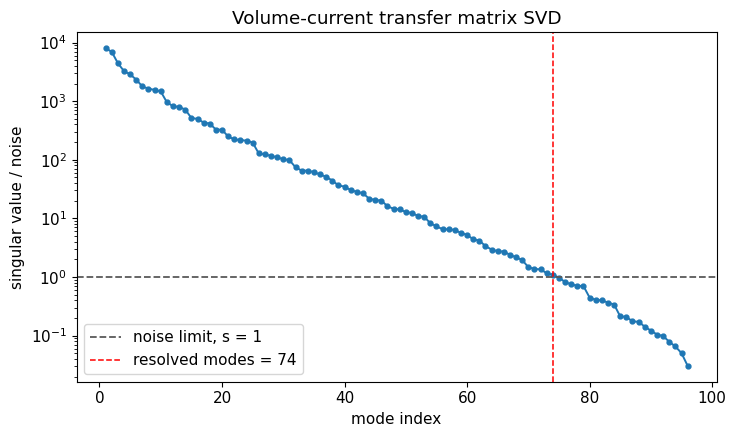

In [36]:
noise_sigma_nT = NOISE_DENSITY_FT_PER_SQRT_HZ * 1.0e-6 / np.sqrt(MEASUREMENT_TIME_S)
Tn = T / noise_sigma_nT

U, svals, Vt = np.linalg.svd(Tn, full_matrices=False)
resolved = svals > SVD_NOISE_THRESHOLD
n_resolved = int(np.count_nonzero(resolved))

print("noise sigma [nT]:", noise_sigma_nT)
print("noise sigma [fT]:", noise_sigma_nT * 1e6)
print("normalized T shape:", Tn.shape)
print("largest singular value:", float(svals[0]))
print("smallest singular value:", float(svals[-1]))
print("resolved modes s > 1:", n_resolved)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
mode_index = np.arange(1, svals.size + 1)
ax.semilogy(mode_index, svals, "o-", ms=3.5, lw=1.4)
ax.axhline(SVD_NOISE_THRESHOLD, color="0.35", linestyle="--", linewidth=1.3, label="noise limit, s = 1")
if n_resolved > 0:
    ax.axvline(n_resolved, color="red", linestyle="--", linewidth=1.1, label=f"resolved modes = {n_resolved}")
ax.set_title("Volume-current transfer matrix SVD")
ax.set_xlabel("mode index")
ax.set_ylabel("singular value / noise")
ax.legend()
plt.tight_layout()
plt.show()


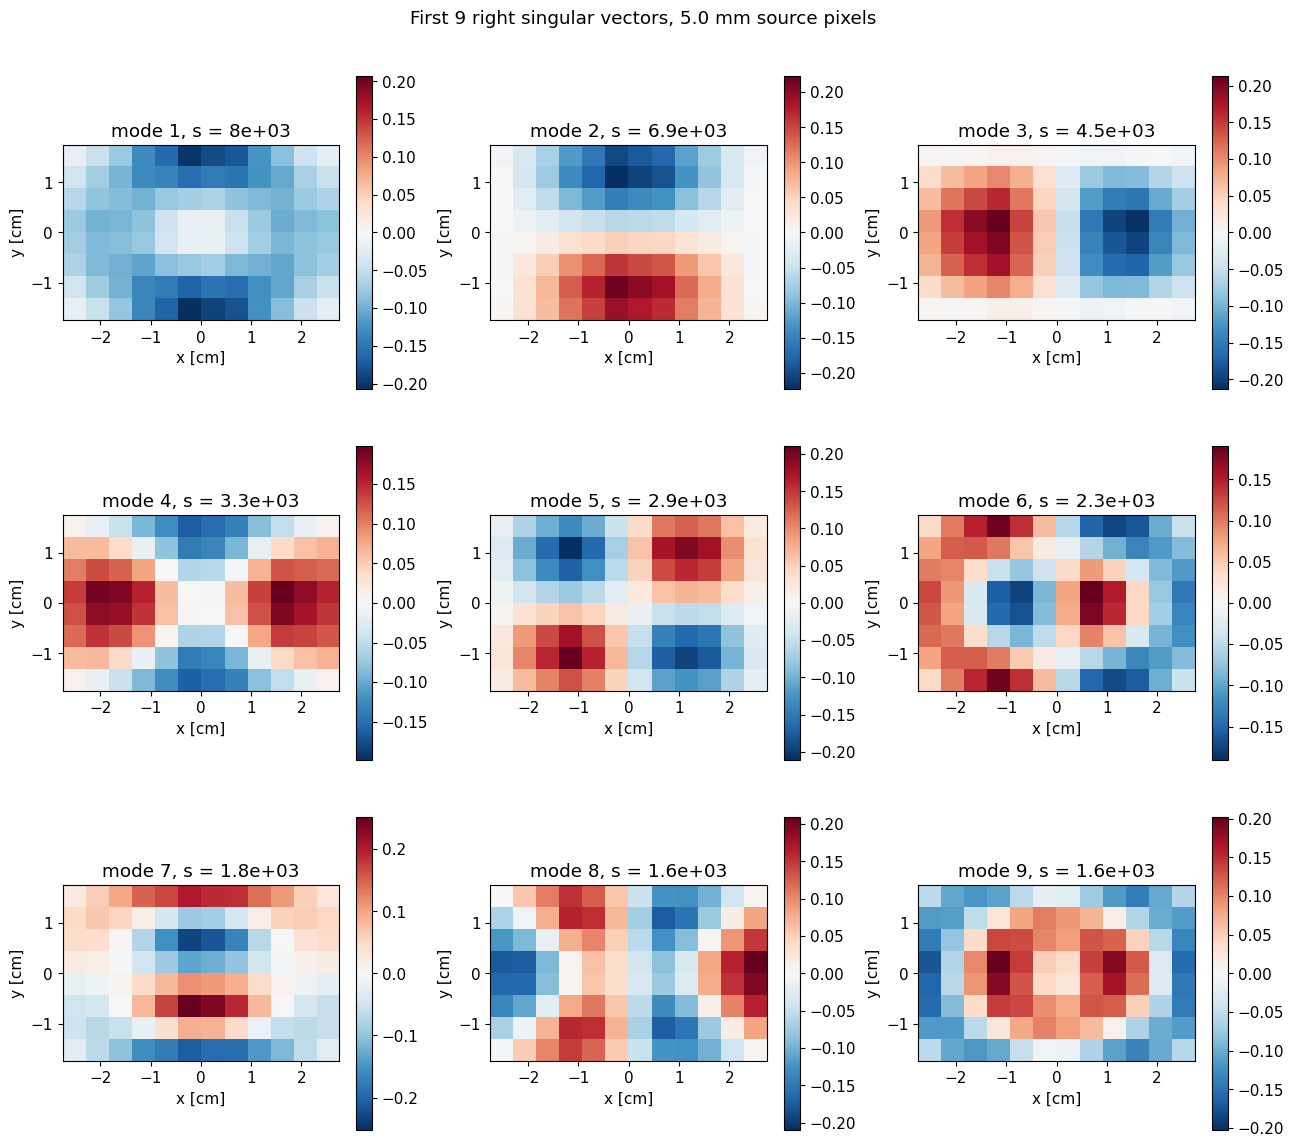

In [37]:
N_MODES_TO_PLOT = min(N_SVD_MODES_TO_PLOT, Vt.shape[0])
ncols = 3
nrows = int(np.ceil(N_MODES_TO_PLOT / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13.0, 4.0 * nrows))
axes = np.atleast_1d(axes).ravel()

for mode_idx in range(N_MODES_TO_PLOT):
    mode_grid, mode_extent_cm, _, _ = pixel_grid(pixel_xy, Vt[mode_idx])
    vmax = max(float(np.nanmax(np.abs(mode_grid))), 1e-30)
    ax = axes[mode_idx]
    im = ax.imshow(mode_grid, origin="lower", extent=mode_extent_cm, aspect="equal", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    add_outlines(ax, geometry, edgecolor="black", scar=False)
    ax.set_title(f"mode {mode_idx + 1}, s = {svals[mode_idx]:.2g}")
    ax.set_xlabel("x [cm]")
    ax.set_ylabel("y [cm]")
    fig.colorbar(im, ax=ax, shrink=0.8)

for ax in axes[N_MODES_TO_PLOT:]:
    ax.set_visible(False)

fig.suptitle(f"First {N_MODES_TO_PLOT} right singular vectors, {TRANSFER_PIXEL_SIZE_M * 1000:.1f} mm source pixels")
plt.tight_layout()
plt.show()


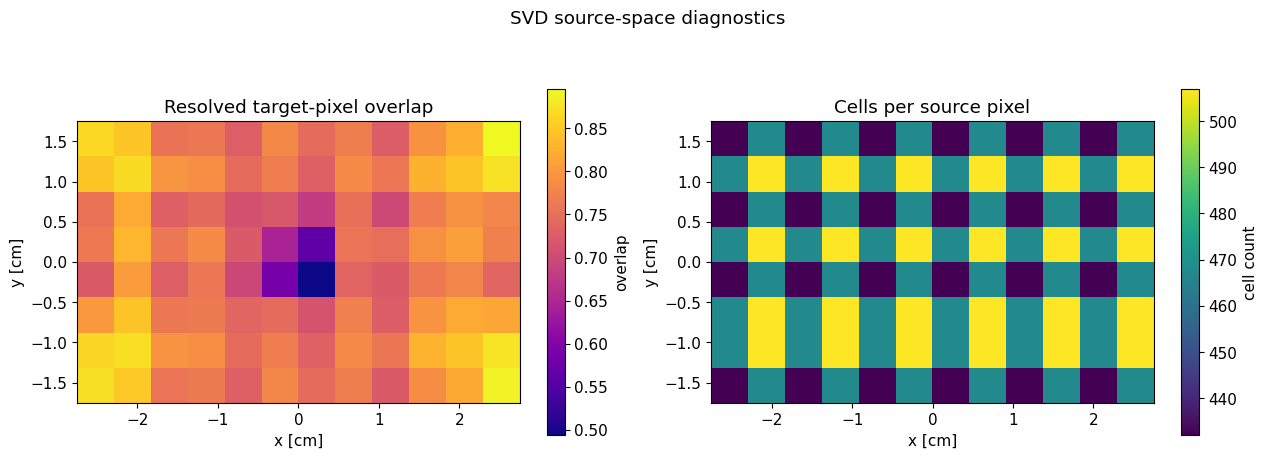

pixel overlap min/max: 0.49374500197090443 0.8959885766165334


In [38]:
# Since the transfer columns already are 5 mm source pixels, target-pixel overlap
# is simply the resolved-source-space energy of each pixel basis vector.
if n_resolved == 0:
    overlap = np.zeros(Vt.shape[1])
else:
    overlap = np.sum(Vt[resolved, :] ** 2, axis=0)

overlap_grid, overlap_extent_cm, _, _ = pixel_grid(pixel_xy, overlap)
count_grid, count_extent_cm, _, _ = pixel_grid(pixel_xy, pixel_n)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.9))
for ax, values, extent_cm, title, cmap, label in [
    (axes[0], overlap_grid, overlap_extent_cm, "Resolved target-pixel overlap", "plasma", "overlap"),
    (axes[1], count_grid, count_extent_cm, "Cells per source pixel", "viridis", "cell count"),
]:
    im = ax.imshow(values, origin="lower", extent=extent_cm, aspect="equal", cmap=cmap)
    add_outlines(ax, geometry, edgecolor="white", scar=False)
    ax.set_xlabel("x [cm]")
    ax.set_ylabel("y [cm]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.82, label=label)
fig.suptitle("SVD source-space diagnostics")
plt.tight_layout()
plt.show()

print("pixel overlap min/max:", float(np.nanmin(overlap)), float(np.nanmax(overlap)))


Voxelized sigma map shape: (20, 30, 2)
nx, ny, nz = 30 20 2
Number of voxels: 1200
Number of scar voxels: 160


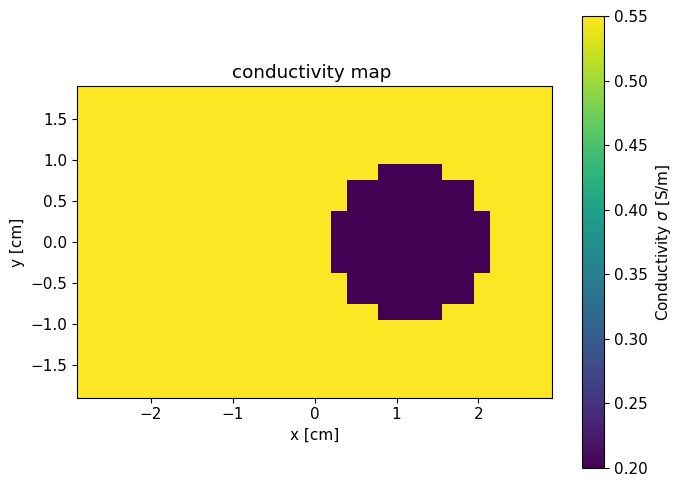

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Voxelized sigma map based on your SimPEG dimensions
# ============================================================

# Tissue dimensions
tissue_size_x = 0.06    # m
tissue_size_y = 0.04    # m
tissue_size_z = 0.002   # m

# Tissue center
tissue_center = np.array([0.0, 0.0, -0.002])

# Voxel size, same as your fine SimPEG mesh
dx = 0.002     # m
dy = 0.002     # m
dz = 0.0008    # m

# Conductivity values
sigma_tissue = 0.55     # S/m
sigma_scar = 0.20       # S/m

# Scar geometry
scar_center = np.array([0.012, 0.0, -0.002])  # m
scar_radius = 0.010                           # m
scar_z_thickness = tissue_size_z              # full tissue depth

# ============================================================
# Build voxel cell centers
# ============================================================

nx = int(np.round(tissue_size_x / dx))
ny = int(np.round(tissue_size_y / dy))
nz = int(np.round(tissue_size_z / dz))

# Make voxel centers
x = np.linspace(
    -tissue_size_x / 2 + dx / 2,
     tissue_size_x / 2 - dx / 2,
    nx
)

y = np.linspace(
    -tissue_size_y / 2 + dy / 2,
     tissue_size_y / 2 - dy / 2,
    ny
)

z = np.linspace(
    tissue_center[2] - tissue_size_z / 2 + dz / 2,
    tissue_center[2] + tissue_size_z / 2 - dz / 2,
    nz
)

X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

# ============================================================
# Assign conductivity to each voxel
# ============================================================

sigma_voxels = np.full(X.shape, sigma_tissue)

scar_mask = (
    (X - scar_center[0])**2
    + (Y - scar_center[1])**2
    <= scar_radius**2
) & (
    np.abs(Z - scar_center[2]) <= scar_z_thickness / 2
)

sigma_voxels[scar_mask] = sigma_scar

print("Voxelized sigma map shape:", sigma_voxels.shape)
print("nx, ny, nz =", nx, ny, nz)
print("Number of voxels:", sigma_voxels.size)
print("Number of scar voxels:", np.count_nonzero(scar_mask))

# ============================================================
# Plot middle z-slice
# ============================================================

iz = nz // 2

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    sigma_voxels[:, :, iz],
    origin="lower",
    extent=[
        x.min() * 100, x.max() * 100,
        y.min() * 100, y.max() * 100
    ],
    aspect="equal",
    cmap="viridis",
    interpolation="nearest"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Conductivity $\sigma$ [S/m]")

ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title(
    rf"conductivity map "
)

# Optional scar boundary for reference
theta = np.linspace(0, 2*np.pi, 400)
scar_x = (scar_center[0] + scar_radius * np.cos(theta)) * 100
scar_y = (scar_center[1] + scar_radius * np.sin(theta)) * 100

plt.tight_layout()
plt.show()

## Outputs kept for later cells

Main arrays now use shorter names:

- `sigma`, `sigma0`: scar and healthy conductivity models.
- `A0`, `B1`, `E0`: coil vector potential, primary field, and drive field.
- `v3_point`: point-pickup result for the scar model.
- `disk_imag`, `disk0_imag`, `contrast_imag`: receiving-disk averaged scar, healthy, and contrast maps.
- `T`: transfer matrix from 5 mm conductivity pixels to disk-averaged `Im(Bz)`.
- `svals`, `Vt`, `overlap`: SVD diagnostics.

The notebook intentionally uses only the cell-centred volume-current Biot-Savart sum for measured secondary fields.
